# Predictive Maintenance — Industrial Machine Failure Classification

### Predictive Maintenance — Machine Failure Classification

### Advanced Machine Learning Methods — Final Applied Project

This project builds and evaluates a binary classification model to predict machine failure using the AI4I 2020 Predictive Maintenance Dataset.

The workflow follows the methods taught in Days 1–3 of the Advanced Machine Learning Methods course: honest validation, gradient boosting, class imbalance analysis, decision-threshold selection, Optuna tuning, model interpretability, probability calibration, and evidence-based final model selection.

In [1]:
!pip -q install lightgbm xgboost shap optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 11.2 MB/s eta 0:00:00


In [2]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

import lightgbm as lgb
import xgboost as xgb
import shap
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 50)

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

IMAGE_DIR = Path("images")
RESULT_DIR = Path("results")

IMAGE_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

print("LightGBM:", lgb.__version__)
print("XGBoost :", xgb.__version__)
print("SHAP    :", shap.__version__)
print("Optuna  :", optuna.__version__)

LightGBM: 4.6.0
XGBoost : 3.4.1
SHAP    : 0.52.0
Optuna  : 5.0.0


## 0. Problem and Dataset Selection

**Problem statement:**  
The objective is to predict whether the current operating condition of an industrial machine will result in a machine failure, so that high-risk cases can be flagged for preventive maintenance inspection before continued operation.

**Target variable:** `Machine failure`  
**Positive class (=1) means:** A machine failure occurred.

**Prediction moment:**  
The prediction is made immediately before deciding whether the current operating instance should continue normally or be referred for maintenance, using only operating information available before the failure outcome is known.

**Decision supported:**  
Whether to flag the current machine/process condition for preventive maintenance inspection or allow normal operation.

**Acted on by:**  
Maintenance / operations team.

**Dataset:** AI4I 2020 Predictive Maintenance Dataset

**Source / link:**  
https://archive.ics.uci.edu/dataset/601/ai4i

**Provider:** UCI Machine Learning Repository

**Dataset citation:**  
AI4I 2020 Predictive Maintenance Dataset. UCI Machine Learning Repository. DOI: 10.24432/C5HS5C.

**Licence / terms:**  
Creative Commons Attribution 4.0 International (CC BY 4.0). Redistribution is permitted with appropriate attribution.

**Size:** 10,000 rows × 14 columns

**Class balance:**  
Positive = 339 (3.39%)  
Negative = 9,661 (96.61%)


**Structural notes:**
- Date / time columns: none
- Group / repeated-entity columns: none; each Product ID represents one recorded product instance
- ID columns: `UDI` / `UID`, `Product ID`
- Possible post-outcome / target-leakage columns: `TWF`, `HDF`, `PWF`, `OSF`, `RNF`

In [3]:
DATA_PATH = "PredictiveـMaintenanceـDataset.csv"
TARGET = "Machine failure"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

assert TARGET in df.columns, f"Target column '{TARGET}' was not found."

Dataset loaded successfully.
Shape: (10000, 14)

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## 1. Project Overview

This project develops an end-to-end predictive-maintenance classification system for detecting machine-failure risk from operational sensor and process variables.

The objective is not only to train a strong model, but also to obtain an honest estimate of its performance, choose a defensible decision threshold, evaluate probability calibration, explain individual predictions, and select a final model based on evidence rather than on a single performance metric.

## 2. Business Problem

Unexpected equipment failure can interrupt production and create avoidable maintenance and operational costs.

The model is intended to support a maintenance team before a failure outcome is known. For each operating instance, it estimates machine-failure risk from the available process measurements. That score can then be converted into a decision to either continue normal operation or flag the instance for maintenance inspection.

The positive class is `Machine failure = 1`.

Because the dataset documentation does not provide a defensible monetary cost for a missed failure or a false maintenance alert, this project will **not invent a business cost matrix**. Instead, the decision threshold will be selected using the F1 score, which provides an assumption-light balance between precision and recall.

This limitation is stated explicitly because the project guideline requires business costs to be documented rather than invented.

## 3. Dataset Overview

This section inspects the dataset structure, target balance, feature types, missing values, and high-cardinality columns before modelling.

The original AI4I dataset contains product identifiers, one categorical product-quality variable, five operational measurements, the binary machine-failure target, and five failure-mode target columns.

The positive class is rare, so accuracy alone would be misleading. PR-AUC, recall, precision and the confusion matrix will therefore receive particular attention.

In [4]:
print("=== DATASET SHAPE ===")
print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n=== TARGET COUNTS ===")
print(df[TARGET].value_counts().sort_index())

print("\n=== TARGET PERCENTAGES ===")
print((df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2))

print("\nPositive-class base rate:")
print(f"{df[TARGET].mean():.4f} ({df[TARGET].mean():.2%})")

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING-VALUE SHARE ===")
print(df.isna().mean().sort_values(ascending=False))

print("\n=== UNIQUE VALUES ===")
print(df.nunique().sort_values(ascending=False))

=== DATASET SHAPE ===
Rows   : 10,000
Columns: 14

=== TARGET COUNTS ===
Machine failure
0    9661
1     339
Name: count, dtype: int64

=== TARGET PERCENTAGES ===
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Positive-class base rate:
0.0339 (3.39%)

=== DATA TYPES ===
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

=== MISSING-VALUE SHARE ===
UDI                        0.0
Product ID                 0.0
Type                       0.0
Air temperature [K]        0.0
Process temperature [K]    0.0
Rotational speed

In [5]:
ID_COLS = [c for c in ["UDI", "UID", "Product ID"] if c in df.columns]

FAILURE_MODE_COLS = [
    c for c in ["TWF", "HDF", "PWF", "OSF", "RNF"]
    if c in df.columns
]

DATE_COLS = []

CATEGORICAL_COLS = [
    c for c in ["Type"]
    if c in df.columns
]

NUMERIC_COLS_RAW = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in [TARGET] + ID_COLS + FAILURE_MODE_COLS
]

print("ID columns               :", ID_COLS)
print("Date/time columns        :", DATE_COLS if DATE_COLS else "none")
print("Categorical columns      :", CATEGORICAL_COLS)
print("Numeric predictive cols  :", NUMERIC_COLS_RAW)
print("Leakage-suspect columns  :", FAILURE_MODE_COLS)

ID columns               : ['UDI', 'Product ID']
Date/time columns        : none
Categorical columns      : ['Type']
Numeric predictive cols  : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Leakage-suspect columns  : ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']


### Dataset Overview — Findings

- The dataset contains 10,000 rows and 14 columns.
- The positive class represents only about 3.39% of the observations, so this is a strongly imbalanced binary-classification problem.
- No missing values are expected according to the dataset documentation; this is verified above.
- `Type` is categorical.
- Temperature, rotational speed, torque and tool wear are numerical operational variables.
- `UDI` / `UID` and `Product ID` are identifiers and should not be predictive features.
- `TWF`, `HDF`, `PWF`, `OSF` and `RNF` are not legitimate predictors of the overall target because `Machine failure` is defined from these failure modes. Including them would directly expose information about the target.
- The dataset contains no timestamp and no repeated machine identifier suitable for time-aware or group-aware validation.

## 4. Validation Strategy

We use **Stratified K-Fold cross-validation** because the rows are treated as independent observations, there is no meaningful deployment timestamp in the dataset, and there is no repeated machine/customer/entity identifier across rows.

Stratification is important because machine failures are rare. Each fold should therefore preserve approximately the same failure rate as the complete modelling sample.

This mirrors the available deployment framing because future predictions will be made for new independent operating instances with the same set of pre-outcome operational variables.

Before any modelling decisions are made, the complete dataset is divided into:

- **Training portion: 60%** — used for cross-validation, baseline modelling, imbalance analysis, threshold selection and Optuna.
- **Calibration portion: 20%** — reserved for probability-calibration assessment and fitting the calibrator.
- **Final hold-out: 20%** — untouched until the final evaluation.

Leakage controls applied:
- Removed identifiers: `UDI` / `UID`, `Product ID`
- Removed target-derived failure-mode columns: `TWF`, `HDF`, `PWF`, `OSF`, `RNF`
- Grouping key: not applicable; rows are treated as independent
- Time cut-off: not applicable; no time dimension is supplied
- No learned imputer, scaler or target encoder is fitted outside cross-validation
- LightGBM handles the low-cardinality `Type` variable natively after converting it to pandas categorical dtype

## 5. Data Preparation

Data preparation is intentionally limited.

The identifiers are removed because they identify observations rather than describing machine condition. The five failure-mode columns are removed because they are components of the target definition and would create direct target leakage.

No feature engineering is added.

No imputation is required if the missing-value inspection confirms the documented absence of missing values. `Type` is converted to pandas `category` so LightGBM can handle it natively.

Leakage inspection covers all five required types:

1. **Post-outcome / target leakage:** `TWF`, `HDF`, `PWF`, `OSF`, `RNF` removed.
2. **ID leakage:** `UDI` / `UID` and `Product ID` removed.
3. **Temporal leakage:** not applicable because no time variable is supplied.
4. **Group leakage:** not applicable because there is one row per recorded product instance and no repeated entity key is used.
5. **Preprocessing leakage:** no learned transformation is fitted on the full dataset outside the training folds.

In [6]:
print("=== AUTOMATED NUMERIC LEAKAGE SCREEN ===")

for col in df.select_dtypes(include=np.number).columns:
    if col == TARGET:
        continue

    s = df[col].fillna(df[col].median())

    try:
        auc = roc_auc_score(df[TARGET], s)
        auc = max(auc, 1 - auc)

        if auc > 0.85:
            print("INVESTIGATE:", col, "AUC =", round(auc, 3))
    except ValueError:
        pass

print("\nAutomated screening is only a warning system.")
print("Structural knowledge is still required to identify target-derived columns.")

=== AUTOMATED NUMERIC LEAKAGE SCREEN ===

Automated screening is only a warning system.
Structural knowledge is still required to identify target-derived columns.


In [7]:
DROP_COLS = ID_COLS + FAILURE_MODE_COLS

X = df.drop(columns=[TARGET] + DROP_COLS).copy()
y = df[TARGET].astype(int).copy()

# Clean column names for LightGBM compatibility
X.columns = [
    c.replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace(' ', '_')
    for c in X.columns
]

for col in CATEGORICAL_COLS:
    if col in X.columns:
        X[col] = X[col].astype("category")

print("Removed columns:", DROP_COLS)
print("\nFinal modelling features:")
print(X.columns.tolist())

print("\nFinal feature dtypes:")
print(X.dtypes)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Removed columns: ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Final modelling features:
['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']

Final feature dtypes:
Type                     category
Air_temperature_K         float64
Process_temperature_K     float64
Rotational_speed_rpm        int64
Torque_Nm                 float64
Tool_wear_min               int64
dtype: object

X shape: (10000, 6)
y shape: (10000,)


In [8]:
# First: untouched 20% final hold-out.
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Second: 25% of the remaining 80% = 20% of the original data.
X_train, X_calib, y_train, y_calib = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=RANDOM_STATE,
)

# Reset indices for safe positional CV indexing.
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_calib = X_calib.reset_index(drop=True)
y_calib = y_calib.reset_index(drop=True)

X_holdout = X_holdout.reset_index(drop=True)
y_holdout = y_holdout.reset_index(drop=True)

CV5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Training     :", X_train.shape, "| positives:", int(y_train.sum()))
print("Calibration  :", X_calib.shape, "| positives:", int(y_calib.sum()))
print("Final holdout:", X_holdout.shape, "| positives:", int(y_holdout.sum()))

print("\nShares of full dataset:")
print("Training    :", len(X_train) / len(X))
print("Calibration :", len(X_calib) / len(X))
print("Hold-out    :", len(X_holdout) / len(X))
print(X_train.columns.tolist())

Training     : (6000, 6) | positives: 203
Calibration  : (2000, 6) | positives: 68
Final holdout: (2000, 6) | positives: 68

Shares of full dataset:
Training    : 0.6
Calibration : 0.2
Hold-out    : 0.2
['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']


## 6. Baseline Model

The baseline is a LightGBM gradient-boosted tree classifier.

LightGBM is appropriate because the dataset is tabular, contains a mix of numerical and categorical information, and is small enough for repeated cross-validation.

The baseline uses:
- fixed random seed = 42
- low learning rate
- a high estimator ceiling
- early stopping inside every validation fold
- native categorical handling
- five-fold stratified cross-validation

Out-of-fold probabilities are collected for every row in the training portion. These predictions are honest because each row is scored by a model that did not train on that row.

The final hold-out remains untouched.

In [9]:
BASE_PARAMS = dict(
    objective="binary",
    learning_rate=0.03,
    n_estimators=2000,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

print(BASE_PARAMS)

{'objective': 'binary', 'learning_rate': 0.03, 'n_estimators': 2000, 'num_leaves': 31, 'min_child_samples': 40, 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [10]:
def cross_validate_lgbm(X_data, y_data, params, cv):
    """
    Stratified cross-validation with early stopping inside every fold.

    Returns:
    - honest out-of-fold probabilities
    - per-fold metrics
    - fitted fold models
    """

    oof = np.zeros(len(X_data))
    fold_rows = []
    fold_models = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_data, y_data), start=1):

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_data.iloc[tr_idx],
            y_data.iloc[tr_idx],
            eval_set=[(
                X_data.iloc[va_idx],
                y_data.iloc[va_idx]
            )],
            eval_metric="average_precision",
            callbacks=[
                lgb.early_stopping(100, verbose=False)
            ],
        )

        p = model.predict_proba(X_data.iloc[va_idx])[:, 1]
        oof[va_idx] = p

        fold_roc = roc_auc_score(y_data.iloc[va_idx], p)
        fold_pr = average_precision_score(y_data.iloc[va_idx], p)

        fold_rows.append({
            "fold": fold,
            "roc_auc": fold_roc,
            "pr_auc": fold_pr,
            "best_iteration": model.best_iteration_,
        })

        fold_models.append(model)

        print(
            f"Fold {fold}: "
            f"ROC-AUC={fold_roc:.4f} | "
            f"PR-AUC={fold_pr:.4f} | "
            f"trees={model.best_iteration_}"
        )

    return oof, pd.DataFrame(fold_rows), fold_models

In [11]:
start = time.perf_counter()

oof_baseline, baseline_folds, baseline_fold_models = cross_validate_lgbm(
    X_train,
    y_train,
    BASE_PARAMS,
    CV5
)

baseline_time = time.perf_counter() - start

BASELINE_ROC = roc_auc_score(y_train, oof_baseline)
BASELINE_PR = average_precision_score(y_train, oof_baseline)

print("\n=== BASELINE OOF PERFORMANCE ===")
print(f"ROC-AUC : {BASELINE_ROC:.4f}")
print(f"PR-AUC  : {BASELINE_PR:.4f}")
print(f"Base rate: {y_train.mean():.4f}")

print("\n=== FOLD SPREAD ===")
print(
    f"ROC-AUC: {baseline_folds['roc_auc'].mean():.4f} "
    f"± {baseline_folds['roc_auc'].std():.4f}"
)

print(
    f"PR-AUC : {baseline_folds['pr_auc'].mean():.4f} "
    f"± {baseline_folds['pr_auc'].std():.4f}"
)

print(f"\nTraining time: {baseline_time:.1f} seconds")

baseline_folds

Fold 1: ROC-AUC=0.9806 | PR-AUC=0.8606 | trees=191
Fold 2: ROC-AUC=0.9825 | PR-AUC=0.7900 | trees=230
Fold 3: ROC-AUC=0.9363 | PR-AUC=0.6556 | trees=130
Fold 4: ROC-AUC=0.9852 | PR-AUC=0.8601 | trees=254
Fold 5: ROC-AUC=0.9625 | PR-AUC=0.8135 | trees=251

=== BASELINE OOF PERFORMANCE ===
ROC-AUC : 0.9714
PR-AUC  : 0.7958
Base rate: 0.0338

=== FOLD SPREAD ===
ROC-AUC: 0.9694 ± 0.0205
PR-AUC : 0.7960 ± 0.0841

Training time: 9.0 seconds


,fold,roc_auc,pr_auc,best_iteration
0,1,0.980582,0.860575,191
1,2,0.982457,0.790038,230
2,3,0.936278,0.655647,130
3,4,0.985164,0.860110,254
4,5,0.962478,0.813452,251


Baseline Cross-Validation Interpretation

The baseline LightGBM model achieved an overall OOF ROC-AUC of **0.9714** and PR-AUC of **0.7958**.

The PR-AUC is especially strong relative to the failure base rate of only **3.38%**, indicating that the model is able to rank rare machine-failure cases far better than a random classifier.

Across the five folds, PR-AUC was **0.7960 ± 0.0841**. Most folds performed strongly, although Fold 3 was weaker (PR-AUC = 0.6556). This variability is important to acknowledge because the positive class is rare and each validation fold contains relatively few failure cases.

Early stopping selected between approximately 130 and 254 trees across folds, showing that the model did not require the full 2,000-tree ceiling.

Baseline Model — Interpretation

The baseline is evaluated using out-of-fold predictions rather than training predictions.

The fold mean and standard deviation quantify how much the measured performance changes when the training/validation partition changes.

PR-AUC is interpreted relative to the machine-failure base rate rather than against 0.5. A model whose PR-AUC is substantially above the approximately 3.4% positive-class rate has learned useful ranking information for the rare failure class.

The baseline model is intentionally not tuned at this stage. Its purpose is to provide a reproducible reference that later methods must beat.

## 7. Imbalanced Learning

Machine failure is rare in this dataset, so class imbalance must be analysed explicitly.

The baseline failure rate is approximately 3.4%. A model could therefore obtain very high accuracy by predicting "no failure" for nearly every row, while detecting few actual failures.

The imbalance lever evaluated here is **class weighting**, using `scale_pos_weight = n_negative / n_positive`.

Class weighting changes the contribution of positive examples to the boosting objective without duplicating or synthesising rows.

The same cross-validation scheme is used before and after weighting so that the comparison is fair.

Because weighting can distort probability calibration, PR-AUC and ROC-AUC are measured before and after rather than assuming that weighting improves the model.

In [12]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

SCALE_POS_WEIGHT = negative_count / positive_count

print("Negative rows:", negative_count)
print("Positive rows:", positive_count)
print("Positive share:", round(y_train.mean(), 4))
print("scale_pos_weight:", round(SCALE_POS_WEIGHT, 2))

Negative rows: 5797
Positive rows: 203
Positive share: 0.0338
scale_pos_weight: 28.56


In [13]:
WEIGHTED_PARAMS = {
    **BASE_PARAMS,
    "scale_pos_weight": SCALE_POS_WEIGHT,
}

start = time.perf_counter()

oof_weighted, weighted_folds, weighted_fold_models = cross_validate_lgbm(
    X_train,
    y_train,
    WEIGHTED_PARAMS,
    CV5
)

weighted_time = time.perf_counter() - start

WEIGHTED_ROC = roc_auc_score(y_train, oof_weighted)
WEIGHTED_PR = average_precision_score(y_train, oof_weighted)

print("\nWeighted model complete.")
print(f"ROC-AUC: {WEIGHTED_ROC:.4f}")
print(f"PR-AUC : {WEIGHTED_PR:.4f}")
print(f"Mean predicted score: {oof_weighted.mean():.4f}")
print(f"Actual base rate    : {y_train.mean():.4f}")
print(f"Training time       : {weighted_time:.1f} seconds")

Fold 1: ROC-AUC=0.9782 | PR-AUC=0.8532 | trees=473
Fold 2: ROC-AUC=0.9817 | PR-AUC=0.8176 | trees=337
Fold 3: ROC-AUC=0.9399 | PR-AUC=0.6490 | trees=374
Fold 4: ROC-AUC=0.9807 | PR-AUC=0.8526 | trees=338
Fold 5: ROC-AUC=0.9722 | PR-AUC=0.8259 | trees=248

Weighted model complete.
ROC-AUC: 0.9698
PR-AUC : 0.7878
Mean predicted score: 0.0429
Actual base rate    : 0.0338
Training time       : 29.9 seconds


Class-Weighted Model Interpretation

Applying class weighting did not improve ranking performance.

The weighted model achieved ROC-AUC = **0.9698** and PR-AUC = **0.7878**, compared with ROC-AUC = **0.9714** and PR-AUC = **0.7958** for the unweighted baseline.

The mean predicted score increased from the natural failure rate toward **0.0429**, compared with an actual base rate of **0.0338**, showing that class weighting shifted the score distribution upward.

Therefore, weighting changed the operating behaviour of the model but did not improve its overall ability to rank machine failures.

In [14]:
def summarise_predictions(y_true, proba, threshold=0.5, label=""):
    pred = (np.asarray(proba) >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    return {
        "model": label,
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "threshold": threshold,
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "flagged": int(pred.sum()),
        "mean_score": float(np.mean(proba)),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

In [15]:
imbalance_table = pd.DataFrame([
    summarise_predictions(
        y_train,
        oof_baseline,
        threshold=0.5,
        label="Unweighted"
    ),
    summarise_predictions(
        y_train,
        oof_weighted,
        threshold=0.5,
        label="Class weighted"
    ),
])

display_cols = [
    "model",
    "roc_auc",
    "pr_auc",
    "precision",
    "recall",
    "f1",
    "flagged",
    "mean_score",
]

print(
    imbalance_table[display_cols]
    .round(4)
    .to_string(index=False)
)

         model  roc_auc  pr_auc  precision  recall     f1  flagged  mean_score
    Unweighted   0.9714  0.7958     0.8759  0.5911 0.7059      137      0.0289
Class weighted   0.9698  0.7878     0.7032  0.7586 0.7299      219      0.0429


Imbalance-Lever Selection

The class-weighted model produced a PR-AUC change of **−0.0080**, so it did not improve the ranking performance of the baseline.

This difference is also very small relative to the observed fold variability. Therefore, there is no evidence that class weighting provides a reliable improvement.

The **unweighted LightGBM baseline is carried forward**. Class imbalance will instead be handled at the decision layer through deliberate threshold selection.

Imbalance Comparison Interpretation

At the default threshold of 0.5, class weighting changed the operating point substantially.

The unweighted model achieved **87.59% precision** and **59.11% recall**, flagging 137 cases. The weighted model increased recall to **75.86%**, but precision fell to **70.32%**, and the number of flagged cases increased to 219.

This shows that weighting made the model more aggressive in identifying failures, but the improvement in recall came at the cost of more false alarms.

Because PR-AUC decreased from **0.7958 to 0.7878**, the weighting did not improve ranking quality. The same recall/precision trade-off can instead be controlled later through the decision threshold.

In [16]:
BASELINE_PR_STD = baseline_folds["pr_auc"].std()

IMBALANCE_NOISE_BAR = 2 * BASELINE_PR_STD

weighting_gain = WEIGHTED_PR - BASELINE_PR

print(f"Baseline PR-AUC : {BASELINE_PR:.4f}")
print(f"Weighted PR-AUC : {WEIGHTED_PR:.4f}")
print(f"Gain            : {weighting_gain:+.4f}")
print(f"2 × fold std    : {IMBALANCE_NOISE_BAR:.4f}")

if weighting_gain > IMBALANCE_NOISE_BAR:
    CARRY_FORWARD = "weighted"
    oof_pre_tune = oof_weighted
    PRE_TUNE_PARAMS = WEIGHTED_PARAMS.copy()
    PRE_TUNE_FOLDS = weighted_folds.copy()

    print("\nVerdict: class weighting produced a material PR-AUC improvement.")
    print("The weighted configuration is carried forward.")
else:
    CARRY_FORWARD = "unweighted"
    oof_pre_tune = oof_baseline
    PRE_TUNE_PARAMS = BASE_PARAMS.copy()
    PRE_TUNE_FOLDS = baseline_folds.copy()

    print("\nVerdict: class weighting did not improve PR-AUC beyond measured fold variability.")
    print("The unweighted configuration is carried forward.")

print("\nCarry-forward configuration:", CARRY_FORWARD)

Baseline PR-AUC : 0.7958
Weighted PR-AUC : 0.7878
Gain            : -0.0080
2 × fold std    : 0.1683

Verdict: class weighting did not improve PR-AUC beyond measured fold variability.
The unweighted configuration is carried forward.

Carry-forward configuration: unweighted


Imbalanced Learning — Interpretation

Class weighting is evaluated as an imbalance treatment rather than assumed to be beneficial.

The important comparison is the change in PR-AUC and ROC-AUC, not merely recall at the default 0.5 threshold. Class weighting can move the score distribution and therefore make a 0.5 cut-off behave very differently even when ranking quality changes little.

The version carried forward is selected using the measured PR-AUC gain relative to the fold-to-fold variability. If the gain is smaller than roughly twice the observed fold spread, it is treated cautiously rather than presented as a clear improvement.

If the weighted version is carried forward, its outputs are treated as scores until probability calibration is assessed later.

## 8. Model Evaluation

The model is evaluated using metrics appropriate for a rare positive class:

- **ROC-AUC:** overall ranking ability.
- **PR-AUC:** ranking quality focused on the rare machine-failure class.
- **Precision:** among cases flagged as failures, how many truly failed.
- **Recall:** among true failures, how many were detected.
- **F1:** balance between precision and recall.
- **Confusion matrix:** actual counts of correct and incorrect decisions.

PR-AUC is compared with the positive-class base rate rather than with 0.5.

Every reported cross-validation score is accompanied by fold variability rather than reported as a single naked number.

In [17]:
EVAL_OOF = oof_pre_tune

eval_roc = roc_auc_score(y_train, EVAL_OOF)
eval_pr = average_precision_score(y_train, EVAL_OOF)

default_summary = summarise_predictions(
    y_train,
    EVAL_OOF,
    threshold=0.5,
    label=f"{CARRY_FORWARD} @ 0.5"
)

print("=== OOF RANKING METRICS ===")
print(f"ROC-AUC : {eval_roc:.4f}")
print(f"PR-AUC  : {eval_pr:.4f}")
print(f"Base rate: {y_train.mean():.4f}")
print(f"PR-AUC lift over base rate: {eval_pr / y_train.mean():.2f}x")

print("\n=== DEFAULT THRESHOLD = 0.50 ===")
print(f"Precision: {default_summary['precision']:.2%}")
print(f"Recall   : {default_summary['recall']:.2%}")
print(f"F1       : {default_summary['f1']:.4f}")
print(f"Flagged  : {default_summary['flagged']:,}")

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_train,
        (EVAL_OOF >= 0.5).astype(int)
    )
)

print("\nFold PR-AUC:")
print(PRE_TUNE_FOLDS[["fold", "pr_auc"]].to_string(index=False))

print(
    f"\nMean ± std PR-AUC: "
    f"{PRE_TUNE_FOLDS['pr_auc'].mean():.4f} "
    f"± {PRE_TUNE_FOLDS['pr_auc'].std():.4f}"
)

=== OOF RANKING METRICS ===
ROC-AUC : 0.9714
PR-AUC  : 0.7958
Base rate: 0.0338
PR-AUC lift over base rate: 23.52x

=== DEFAULT THRESHOLD = 0.50 ===
Precision: 87.59%
Recall   : 59.11%
F1       : 0.7059
Flagged  : 137

Confusion matrix:
[[5780   17]
 [  83  120]]

Fold PR-AUC:
 fold   pr_auc
    1 0.860575
    2 0.790038
    3 0.655647
    4 0.860110
    5 0.813452

Mean ± std PR-AUC: 0.7960 ± 0.0841


OOF Evaluation Interpretation

The selected baseline achieved ROC-AUC = **0.9714** and PR-AUC = **0.7958**, compared with a positive-class base rate of only **0.0338**. The PR-AUC is approximately **23.5 times the base-rate reference**, showing strong ranking ability for the rare failure class.

At the default threshold of 0.5, the confusion matrix is:

- True negatives = **5,780**
- False positives = **17**
- False negatives = **83**
- True positives = **120**

This gives **87.59% precision** and **59.11% recall**. Therefore, alerts generated at 0.5 are usually correct, but approximately 41% of true failures are still missed. This motivates selecting a more suitable threshold rather than keeping the default 0.5.

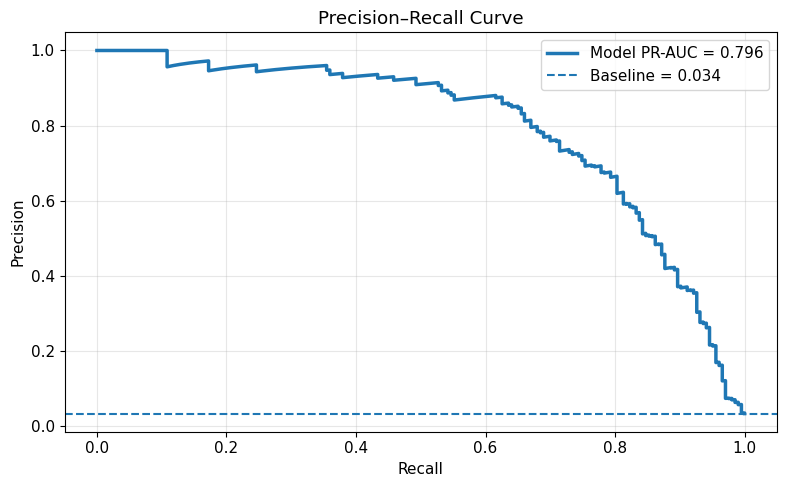

In [18]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(
    y_train,
    EVAL_OOF
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    recall_vals,
    precision_vals,
    lw=2.5,
    label=f"Model PR-AUC = {eval_pr:.3f}"
)

ax.axhline(
    y_train.mean(),
    linestyle="--",
    label=f"Baseline = {y_train.mean():.3f}"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curve")
ax.legend()

plt.tight_layout()
plt.savefig(IMAGE_DIR / "pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Precision–Recall Curve Interpretation

The precision–recall curve remains far above the failure base-rate line for most of its range, confirming strong discrimination for the rare positive class.

At stricter thresholds, the model can achieve very high precision, but only a smaller share of failures is detected. As the threshold is lowered and recall increases, precision gradually falls because more non-failure cases are also flagged.

The overall PR-AUC of approximately **0.796** indicates that the model maintains a strong precision–recall trade-off relative to the **3.4%** random baseline.

## 9. Decision Threshold

The default threshold of 0.5 is replaced with a threshold selected from honest out-of-fold scores.

No documented monetary false-positive or false-negative costs are supplied with this dataset, so an expected-cost rule would require inventing business assumptions. The project therefore uses **maximum F1** as the operating rule.

This rule balances precision and recall without claiming unsupported monetary costs.

The threshold is swept across a wide range. For every candidate threshold, the confusion matrix, precision, recall, F1 and flagged-case rate are calculated.

In [19]:
def threshold_sweep(y_true, proba, lo=0.005, hi=0.995, n=199):

    y_arr = np.asarray(y_true)

    rows = []

    for t in np.linspace(lo, hi, n):

        pred = (np.asarray(proba) >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_arr,
            pred
        ).ravel()

        precision = tp / (tp + fp) if (tp + fp) else 0
        recall = tp / (tp + fn) if (tp + fn) else 0

        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall)
            else 0
        )

        rows.append({
            "threshold": t,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "flagged": tp + fp,
            "flag_rate": (tp + fp) / len(y_arr),
        })

    return pd.DataFrame(rows)

In [20]:
threshold_results = threshold_sweep(
    y_train,
    oof_pre_tune
)

best_threshold_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

INITIAL_THRESHOLD = float(best_threshold_row["threshold"])

print("=== SELECTED OPERATING POINT ===")
print(f"Threshold : {INITIAL_THRESHOLD:.3f}")
print("Rule      : Maximum F1")
print(f"Precision : {best_threshold_row['precision']:.2%}")
print(f"Recall    : {best_threshold_row['recall']:.2%}")
print(f"F1        : {best_threshold_row['f1']:.4f}")
print(f"FP        : {int(best_threshold_row['FP'])}")
print(f"FN        : {int(best_threshold_row['FN'])}")
print(f"Flagged   : {int(best_threshold_row['flagged'])}")
print(f"Flag rate : {best_threshold_row['flag_rate']:.2%}")

=== SELECTED OPERATING POINT ===
Threshold : 0.430
Rule      : Maximum F1
Precision : 84.71%
Recall    : 65.52%
F1        : 0.7389
FP        : 24
FN        : 70
Flagged   : 157
Flag rate : 2.62%


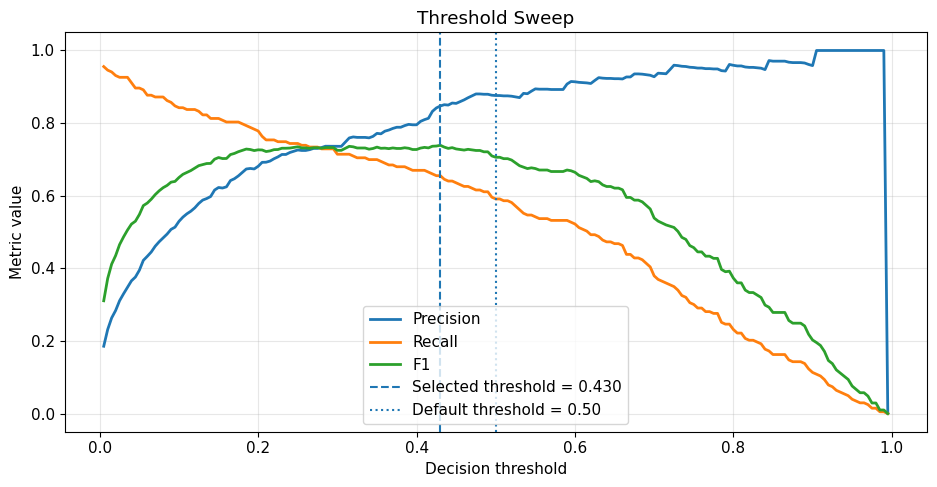

In [21]:
fig, ax = plt.subplots(figsize=(9.5, 5))

ax.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision",
    lw=2,
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall",
    lw=2,
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1",
    lw=2,
)

ax.axvline(
    INITIAL_THRESHOLD,
    linestyle="--",
    label=f"Selected threshold = {INITIAL_THRESHOLD:.3f}"
)

ax.axvline(
    0.5,
    linestyle=":",
    label="Default threshold = 0.50"
)

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.set_title("Threshold Sweep")
ax.legend()

plt.tight_layout()
plt.savefig(
    IMAGE_DIR / "threshold_curve.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

### Threshold Sweep Interpretation

The threshold sweep shows the expected trade-off between precision and recall.

As the threshold increases, precision generally rises because only the highest-risk cases are flagged. However, recall falls because more true failures fall below the decision boundary.

The F1 score reaches its maximum near **0.43**, which provides the best balance between precision and recall under the selected operating rule. This is lower than the default 0.5 threshold, allowing the system to capture more true failures while maintaining strong alert quality.

## 10. Hyperparameter Optimization

A small Optuna study is used to test whether systematic hyperparameter optimisation improves the selected LightGBM configuration.

The study:
- optimises PR-AUC
- uses three-fold stratified cross-validation inside every trial
- uses the same training portion only
- never touches the calibration or final hold-out sets
- uses a seeded TPE sampler
- searches only parameters taught in the LightGBM lab
- runs a classroom-sized number of trials

The gain from tuning is compared against the measured fold variability. A small numerical gain is not automatically treated as a meaningful improvement.

In [22]:
CV3 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

FIXED_SCALE_POS_WEIGHT = (
    SCALE_POS_WEIGHT if CARRY_FORWARD == "weighted" else 1.0
)

def objective(trial):

    params = dict(
        objective="binary",
        n_estimators=2000,

        learning_rate=trial.suggest_float(
            "learning_rate",
            0.01,
            0.10,
            log=True
        ),

        num_leaves=trial.suggest_int(
            "num_leaves",
            15,
            63
        ),

        min_child_samples=trial.suggest_int(
            "min_child_samples",
            10,
            120
        ),

        subsample=trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        subsample_freq=1,

        colsample_bytree=trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        reg_lambda=trial.suggest_float(
            "reg_lambda",
            1e-2,
            10,
            log=True
        ),

        scale_pos_weight=FIXED_SCALE_POS_WEIGHT,

        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )

    fold_scores = []

    for tr_idx, va_idx in CV3.split(X_train, y_train):

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_train.iloc[tr_idx],
            y_train.iloc[tr_idx],
            eval_set=[(
                X_train.iloc[va_idx],
                y_train.iloc[va_idx]
            )],
            eval_metric="average_precision",
            callbacks=[
                lgb.early_stopping(100, verbose=False)
            ],
        )

        p = model.predict_proba(
            X_train.iloc[va_idx]
        )[:, 1]

        fold_scores.append(
            average_precision_score(
                y_train.iloc[va_idx],
                p
            )
        )

    return float(np.mean(fold_scores))

In [23]:
N_TRIALS = 15

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)

study.optimize(
    objective,
    n_trials=N_TRIALS
)

print("Number of trials:", N_TRIALS)
print(f"Best CV PR-AUC : {study.best_value:.4f}")

print("\nBest parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

[I 2026-09-09 06:06:06,389] A new study created in memory with name: no-name-fc628543-16ad-48fb-b760-ea74e9ca0864
[I 2026-09-09 06:06:15,421] Trial 0 finished with value: 0.7434427961229478 and parameters: {'learning_rate': 0.023688639503640783, 'num_leaves': 61, 'min_child_samples': 91, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 0.029375384576328288}. Best is trial 0 with value: 0.7434427961229478.
[I 2026-09-09 06:06:24,590] Trial 1 finished with value: 0.740260364222876 and parameters: {'learning_rate': 0.011430983876313222, 'num_leaves': 57, 'min_child_samples': 76, 'subsample': 0.8832290311184181, 'colsample_bytree': 0.608233797718321, 'reg_lambda': 8.123245085588687}. Best is trial 0 with value: 0.7434427961229478.
[I 2026-09-09 06:06:33,840] Trial 2 finished with value: 0.7649854274671751 and parameters: {'learning_rate': 0.06798962421591129, 'num_leaves': 25, 'min_child_samples': 30, 'subsample': 0.6733618039413735, 'colsample_bytree'

Number of trials: 15
Best CV PR-AUC : 0.7969

Best parameters:
learning_rate: 0.04050837781329675
num_leaves: 23
min_child_samples: 17
subsample: 0.9795542149013333
colsample_bytree: 0.9862528132298237
reg_lambda: 2.6619018884890564


Optuna Study Interpretation

Optuna evaluated **15 LightGBM hyperparameter configurations** using cross-validated PR-AUC as the optimisation objective.

The highest trial score was **0.7969**, with a learning rate of approximately 0.041, 23 leaves, 17 minimum child samples, near-full row and feature sampling, and stronger L2 regularisation.

The best Optuna value is treated only as a search result, not as final evidence of improvement. The selected parameters must be re-evaluated under the same fixed five-fold cross-validation used for the baseline.

In [24]:
TUNED_PARAMS = {
    **BASE_PARAMS,
    **study.best_params,
    "scale_pos_weight": FIXED_SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

oof_tuned, tuned_folds, tuned_fold_models = cross_validate_lgbm(
    X_train,
    y_train,
    TUNED_PARAMS,
    CV5
)

TUNED_ROC = roc_auc_score(
    y_train,
    oof_tuned
)

TUNED_PR = average_precision_score(
    y_train,
    oof_tuned
)

PRE_TUNE_PR = average_precision_score(
    y_train,
    oof_pre_tune
)

TUNING_GAIN = TUNED_PR - PRE_TUNE_PR

NOISE_FLOOR = 2 * PRE_TUNE_FOLDS["pr_auc"].std()

print("\n=== TUNING RESULT ===")
print(f"Pre-tune PR-AUC : {PRE_TUNE_PR:.4f}")
print(f"Tuned PR-AUC    : {TUNED_PR:.4f}")
print(f"Gain            : {TUNING_GAIN:+.4f}")
print(f"2 × fold std    : {NOISE_FLOOR:.4f}")

Fold 1: ROC-AUC=0.9871 | PR-AUC=0.8727 | trees=126
Fold 2: ROC-AUC=0.9826 | PR-AUC=0.8052 | trees=170
Fold 3: ROC-AUC=0.9352 | PR-AUC=0.6636 | trees=133
Fold 4: ROC-AUC=0.9846 | PR-AUC=0.8862 | trees=166
Fold 5: ROC-AUC=0.9614 | PR-AUC=0.8106 | trees=206

=== TUNING RESULT ===
Pre-tune PR-AUC : 0.7958
Tuned PR-AUC    : 0.8024
Gain            : +0.0067
2 × fold std    : 0.1683


Hyperparameter Tuning Interpretation

Re-evaluating the best Optuna configuration with the fixed five-fold CV increased PR-AUC from **0.7958 to 0.8024**, a gain of only **+0.0067**.

Although the tuned score is numerically higher, the improvement is very small relative to the observed fold-to-fold variability (**PR-AUC std = 0.0841**).

Therefore, the result does not provide strong evidence that the tuned model is reliably better. The baseline is already strong, and the additional tuning complexity is not justified by such a small improvement.

In [25]:
if TUNING_GAIN > NOISE_FLOOR:

    SELECTED_SINGLE_NAME = "Optuna-tuned LightGBM"
    SELECTED_PARAMS = TUNED_PARAMS.copy()
    SELECTED_OOF = oof_tuned.copy()
    SELECTED_FOLDS = tuned_folds.copy()

    print("Tuned model selected: improvement exceeds the measured noise floor.")

else:

    SELECTED_SINGLE_NAME = (
        "Class-weighted LightGBM"
        if CARRY_FORWARD == "weighted"
        else "Baseline LightGBM"
    )

    SELECTED_PARAMS = PRE_TUNE_PARAMS.copy()
    SELECTED_OOF = oof_pre_tune.copy()
    SELECTED_FOLDS = PRE_TUNE_FOLDS.copy()

    print("Pre-tuned model retained: tuning gain is not clearly above variability.")

print("\nSelected single model:", SELECTED_SINGLE_NAME)

Pre-tuned model retained: tuning gain is not clearly above variability.

Selected single model: Baseline LightGBM


Single-Model Selection

The original baseline LightGBM is retained as the selected single model.

The Optuna-tuned model achieved a slightly higher PR-AUC, but the gain was too small relative to cross-validation variability to justify claiming a reliable improvement.

This follows the evidence-based model-selection principle: a simpler model is preferred when additional complexity does not produce a clearly meaningful performance gain.

In [26]:
final_threshold_results = threshold_sweep(
    y_train,
    SELECTED_OOF
)

final_best_threshold_row = final_threshold_results.loc[
    final_threshold_results["f1"].idxmax()
]

SELECTED_THRESHOLD_RAW = float(
    final_best_threshold_row["threshold"]
)

print("=== THRESHOLD AFTER FINAL SINGLE-MODEL SELECTION ===")
print(f"Model     : {SELECTED_SINGLE_NAME}")
print(f"Rule      : Maximum F1")
print(f"Threshold : {SELECTED_THRESHOLD_RAW:.3f}")
print(f"Precision : {final_best_threshold_row['precision']:.2%}")
print(f"Recall    : {final_best_threshold_row['recall']:.2%}")
print(f"F1        : {final_best_threshold_row['f1']:.4f}")

=== THRESHOLD AFTER FINAL SINGLE-MODEL SELECTION ===
Model     : Baseline LightGBM
Rule      : Maximum F1
Threshold : 0.430
Precision : 84.71%
Recall    : 65.52%
F1        : 0.7389


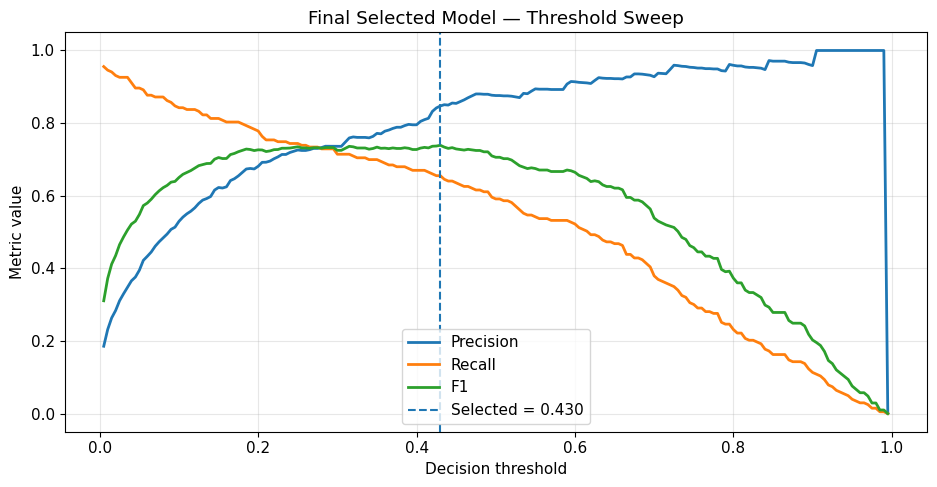

In [27]:
fig, ax = plt.subplots(figsize=(9.5, 5))

ax.plot(
    final_threshold_results["threshold"],
    final_threshold_results["precision"],
    label="Precision",
    lw=2
)

ax.plot(
    final_threshold_results["threshold"],
    final_threshold_results["recall"],
    label="Recall",
    lw=2
)

ax.plot(
    final_threshold_results["threshold"],
    final_threshold_results["f1"],
    label="F1",
    lw=2
)

ax.axvline(
    SELECTED_THRESHOLD_RAW,
    linestyle="--",
    label=f"Selected = {SELECTED_THRESHOLD_RAW:.3f}"
)

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.set_title("Final Selected Model — Threshold Sweep")
ax.legend()

plt.tight_layout()
plt.savefig(
    IMAGE_DIR / "threshold_curve.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

Selected Threshold Interpretation

The maximum-F1 rule selected a decision threshold of **0.430**.

At this threshold, precision is **84.71%**, recall is **65.52%**, and F1 is **0.7389**.

Compared with the default 0.5 threshold, precision decreases slightly, but recall improves substantially from approximately 59% to 66%. The overall F1 score therefore increases.

This operating point deliberately accepts a small increase in false alarms in exchange for detecting a larger share of real machine failures.

## 11. Model Interpretability

Interpretability is evaluated globally and locally.

**Global question:** Which variables does the model rely on most across the population?

**Local question:** Why was one specific operating instance assigned its risk score?

Permutation importance is computed on data not used to fit the explanation model, and SHAP is used to examine feature direction and individual contributions.

A near-threshold case is selected for the local explanation because these are the decisions most likely to be operationally uncertain.

The failure-mode target columns have already been removed, so the explanation should be based only on legitimate pre-outcome machine-condition variables.

In [28]:
X_explain_train, X_explain_valid, y_explain_train, y_explain_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# Use the median number of trees selected during CV
# rather than using the calibration or final hold-out for early stopping.
EXPLAIN_N_ESTIMATORS = int(
    np.median(SELECTED_FOLDS["best_iteration"])
)

EXPLAIN_PARAMS = {
    **SELECTED_PARAMS,
    "n_estimators": max(EXPLAIN_N_ESTIMATORS, 1),
}

explain_model = lgb.LGBMClassifier(
    **EXPLAIN_PARAMS
)

explain_model.fit(
    X_explain_train,
    y_explain_train
)

print("Explanation model fitted.")
print("Trees:", EXPLAIN_N_ESTIMATORS)

Explanation model fitted.
Trees: 230


              feature  importance_mean  importance_std
            Torque_Nm           0.5032          0.0451
    Air_temperature_K           0.4732          0.0176
 Rotational_speed_rpm           0.4159          0.0403
Process_temperature_K           0.3358          0.0269
        Tool_wear_min           0.3228          0.0467
                 Type           0.0466          0.0067


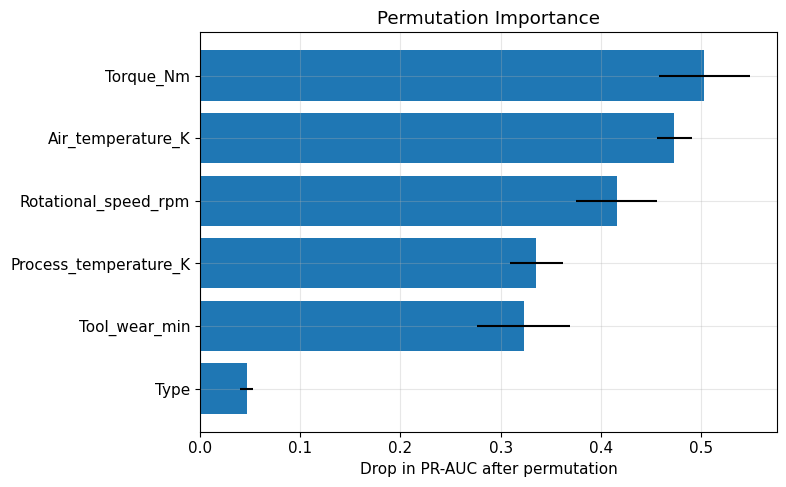

In [29]:
pi = permutation_importance(
    explain_model,
    X_explain_valid,
    y_explain_valid,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
)

permutation_table = pd.DataFrame({
    "feature": X_explain_valid.columns,
    "importance_mean": pi.importances_mean,
    "importance_std": pi.importances_std,
}).sort_values(
    "importance_mean",
    ascending=False
)

print(permutation_table.round(4).to_string(index=False))

top_pi = permutation_table.head(10).sort_values(
    "importance_mean"
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top_pi["feature"],
    top_pi["importance_mean"],
    xerr=top_pi["importance_std"]
)

ax.set_xlabel("Drop in PR-AUC after permutation")
ax.set_title("Permutation Importance")

plt.tight_layout()
plt.show()

Permutation Importance Interpretation

Permutation importance identifies **Torque** as the strongest global predictor, followed by air temperature and rotational speed.

Shuffling `Torque_Nm` causes the largest reduction in PR-AUC, indicating that the model relies heavily on this feature for accurate failure ranking. Air temperature and rotational speed also contribute substantial predictive information.

Process temperature and tool wear have moderate importance, while `Type` contributes relatively little additional information.

These values measure the loss in model performance when a feature's information is disrupted; they should not be interpreted as percentages of causal importance.

In [30]:
X_shap = X_explain_valid.sample(
    min(2000, len(X_explain_valid)),
    random_state=RANDOM_STATE
)

explainer = shap.TreeExplainer(
    explain_model
)

shap_values = explainer(
    X_shap
)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (1500, 6)


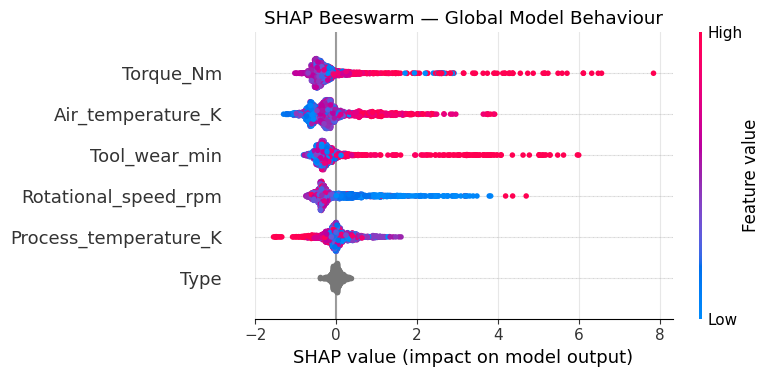

In [31]:
shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)

plt.title("SHAP Beeswarm — Global Model Behaviour")
plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "shap_summary.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Global SHAP Interpretation

The SHAP beeswarm confirms that the model relies most strongly on **torque**, air temperature, tool wear and rotational speed.

High torque values generally produce large positive SHAP values, meaning they push predictions toward higher machine-failure risk. Higher air temperature and greater tool wear also tend to increase predicted risk.

For rotational speed, many low values appear on the positive-risk side, suggesting that low rotational speed can strongly increase predicted risk in some operating conditions. The pattern is nonlinear, however, and should be interpreted as model behaviour rather than as a simple causal relationship.

`Type` has very small SHAP effects for most observations, consistent with its low permutation importance.

In [32]:
p_explain = explain_model.predict_proba(
    X_explain_valid
)[:, 1]

near_idx_position = np.argmin(
    np.abs(p_explain - SELECTED_THRESHOLD_RAW)
)

local_index = X_explain_valid.index[
    near_idx_position
]

local_position_in_shap = np.where(
    X_shap.index == local_index
)[0]

if len(local_position_in_shap) == 0:
    # If the closest case was not inside the SHAP sample,
    # explain the SHAP-sample case closest to the threshold instead.
    p_shap = explain_model.predict_proba(X_shap)[:, 1]
    local_shap_position = int(
        np.argmin(
            np.abs(p_shap - SELECTED_THRESHOLD_RAW)
        )
    )
else:
    local_shap_position = int(
        local_position_in_shap[0]
    )

local_row = X_shap.iloc[
    local_shap_position
]

local_score = explain_model.predict_proba(
    X_shap.iloc[[local_shap_position]]
)[:, 1][0]

print("Selected local case index:", X_shap.index[local_shap_position])
print("Predicted score          :", round(local_score, 4))
print("Decision threshold       :", round(SELECTED_THRESHOLD_RAW, 4))

display(local_row.to_frame("value"))

Selected local case index: 4753
Predicted score          : 0.4317
Decision threshold       : 0.43


,value
Type,H
Air_temperature_K,302.2
Process_temperature_K,311.8
Rotational_speed_rpm,1330
Torque_Nm,62.4
Tool_wear_min,31


Local Case Selection

Case **#4753** was selected because its predicted score (**0.4317**) is almost exactly equal to the chosen decision threshold (**0.430**).

This makes it a useful borderline example for local interpretation: the model classifies the case as high risk, but only by a small margin.

The SHAP waterfall below is therefore used to identify which operating conditions pushed this particular observation above the decision boundary.

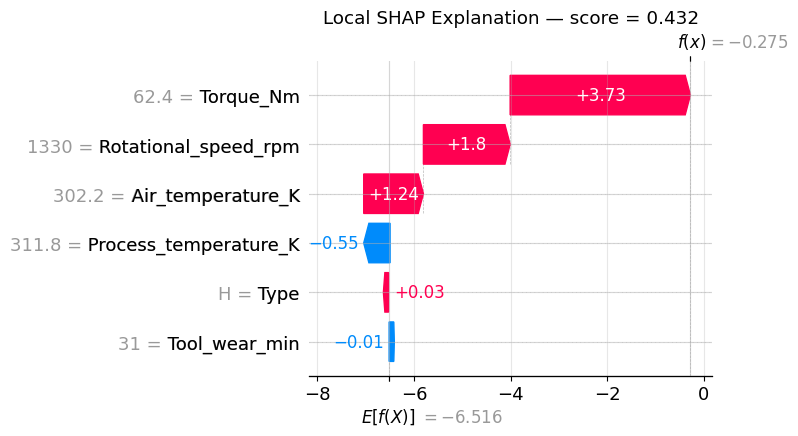

In [33]:
shap.plots.waterfall(
    shap_values[local_shap_position],
    max_display=10,
    show=False
)

plt.title(
    f"Local SHAP Explanation — score = {local_score:.3f}"
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "shap_waterfall.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Local SHAP Interpretation

For case #4753, the largest factor pushing the prediction toward failure is **Torque = 62.4 Nm**, with the strongest positive SHAP contribution.

The next largest positive contributors are **rotational speed = 1330 rpm** and **air temperature = 302.2 K**. Together, these operating conditions push the case above the selected failure threshold.

`Process_temperature_K = 311.8` slightly reduces the predicted risk, while `Type` and the relatively low tool-wear value have very small effects for this individual case.

The SHAP values shown in the waterfall are contributions on the model's raw output scale, not direct percentage-point changes in probability. Their combined effect is transformed by the model into the final predicted probability of approximately **0.432**.

In [34]:
local_contributions = pd.DataFrame({
    "feature": X_shap.columns,
    "value": X_shap.iloc[local_shap_position].astype(str).values,
    "shap_value": shap_values.values[local_shap_position],
})

local_contributions["abs_shap"] = (
    local_contributions["shap_value"].abs()
)

local_contributions = local_contributions.sort_values(
    "abs_shap",
    ascending=False
)

print("=== LARGEST LOCAL CONTRIBUTIONS ===")
print(
    local_contributions[
        ["feature", "value", "shap_value"]
    ]
    .head(10)
    .round(4)
    .to_string(index=False)
)

positive_reasons = (
    local_contributions[
        local_contributions["shap_value"] > 0
    ]
    .head(3)
)

print("\n=== TOP POSITIVE RISK CONTRIBUTORS ===")
print(
    positive_reasons[
        ["feature", "value", "shap_value"]
    ]
    .round(4)
    .to_string(index=False)
)

=== LARGEST LOCAL CONTRIBUTIONS ===
              feature value  shap_value
            Torque_Nm  62.4      3.7338
 Rotational_speed_rpm  1330      1.7968
    Air_temperature_K 302.2      1.2364
Process_temperature_K 311.8     -0.5462
                 Type     H      0.0307
        Tool_wear_min    31     -0.0110

=== TOP POSITIVE RISK CONTRIBUTORS ===
             feature value  shap_value
           Torque_Nm  62.4      3.7338
Rotational_speed_rpm  1330      1.7968
   Air_temperature_K 302.2      1.2364


Local Reason Codes

The three main positive risk contributors for the selected case are:

1. **High torque** contributed strongly to a higher predicted machine-failure risk.
2. **Rotational speed of 1330 rpm** increased the model's predicted failure risk for this operating condition.
3. **Air temperature of 302.2 K** also pushed the prediction toward the failure class.

The process-temperature value partially offset these risk factors, while product type and tool wear had little influence on this individual prediction.

In [35]:
top_global = permutation_table.iloc[0]["feature"]

top_positive = (
    local_contributions[
        local_contributions["shap_value"] > 0
    ]
    .head(3)["feature"]
    .tolist()
)

top_negative = (
    local_contributions[
        local_contributions["shap_value"] < 0
    ]
    .head(1)["feature"]
    .tolist()
)

print("### Written Interpretability Findings")
print()
print(
    f"1. The strongest global predictive feature by permutation importance "
    f"is `{top_global}`."
)

if top_positive:
    print(
        f"2. For the selected near-threshold case, the largest features "
        f"pushing the model toward failure were: {', '.join(top_positive)}."
    )

if top_negative:
    print(
        f"3. The feature `{top_negative[0]}` pushed this case toward a "
        f"lower predicted failure risk."
    )

print(
    "4. These explanations describe how the model uses the variables; "
    "they should not be interpreted as proof of real-world causation."
)

print("\n### Reason Codes")
for i, feature in enumerate(top_positive, start=1):
    print(
        f"{i}. The value of {feature} contributed to a higher predicted "
        f"machine-failure risk for this operating instance."
    )

### Written Interpretability Findings

1. The strongest global predictive feature by permutation importance is `Torque_Nm`.
2. For the selected near-threshold case, the largest features pushing the model toward failure were: Torque_Nm, Rotational_speed_rpm, Air_temperature_K.
3. The feature `Process_temperature_K` pushed this case toward a lower predicted failure risk.
4. These explanations describe how the model uses the variables; they should not be interpreted as proof of real-world causation.

### Reason Codes
1. The value of Torque_Nm contributed to a higher predicted machine-failure risk for this operating instance.
2. The value of Rotational_speed_rpm contributed to a higher predicted machine-failure risk for this operating instance.
3. The value of Air_temperature_K contributed to a higher predicted machine-failure risk for this operating instance.


### Model Interpretability — Interpretation

The permutation-importance ranking describes predictive value at the population level, while the SHAP waterfall explains one individual operating instance.

Positive SHAP contributions increase the model's failure-risk score and negative contributions reduce it.

These results describe **model attribution**, not causation. For example, a large contribution from torque means that the model relied strongly on torque for that prediction; it does not by itself prove that changing torque would causally prevent or produce a failure.

The global importance ranking should also be interpreted cautiously when features are correlated, because permutation importance can underestimate variables whose information is duplicated by another feature.

## 12. Calibration

The selected single LightGBM configuration is now assessed for probability calibration.

The model is fitted only on the 60% training portion. The separate 20% calibration split, which the model has never trained on, is then used to:

1. compare the mean predicted probability with the observed failure rate,
2. calculate the Brier score,
3. create a reliability diagram,
4. fit sigmoid / Platt calibration,
5. re-measure probability quality.

The final 20% hold-out remains untouched.

Sigmoid calibration is used because it was taught in Day 3, is monotonic, preserves ranking order, and is appropriate for a calibration sample of this size.

In [36]:
FINAL_TREE_COUNT = int(
    np.median(
        SELECTED_FOLDS["best_iteration"]
    )
)

FINAL_BASE_PARAMS = {
    **SELECTED_PARAMS,
    "n_estimators": max(FINAL_TREE_COUNT, 1),
    "random_state": RANDOM_STATE,
}

final_base_model = lgb.LGBMClassifier(
    **FINAL_BASE_PARAMS
)

final_base_model.fit(
    X_train,
    y_train
)

p_cal_raw = final_base_model.predict_proba(
    X_calib
)[:, 1]

BRIER_BEFORE = brier_score_loss(
    y_calib,
    p_cal_raw
)

print("Final base model:", SELECTED_SINGLE_NAME)
print("Fixed tree count:", FINAL_TREE_COUNT)

print("\n=== BEFORE CALIBRATION ===")
print(f"Mean predicted probability: {p_cal_raw.mean():.4f}")
print(f"Calibration base rate      : {y_calib.mean():.4f}")
print(f"Brier score                : {BRIER_BEFORE:.4f}")
print(
    f"ROC-AUC                    : "
    f"{roc_auc_score(y_calib, p_cal_raw):.4f}"
)
print(
    f"PR-AUC                     : "
    f"{average_precision_score(y_calib, p_cal_raw):.4f}"
)

Final base model: Baseline LightGBM
Fixed tree count: 230

=== BEFORE CALIBRATION ===
Mean predicted probability: 0.0302
Calibration base rate      : 0.0340
Brier score                : 0.0139
ROC-AUC                    : 0.9757
PR-AUC                     : 0.7836


Calibration Check — Before Calibration

Before applying a calibrator, the selected LightGBM model predicts a mean failure probability of **3.02%** on the calibration set, compared with an observed failure rate of **3.40%**.

These values are already close, suggesting that the raw model is reasonably well calibrated at the portfolio level, although it slightly underestimates the overall failure rate.

The Brier score is **0.0139**, while ROC-AUC = **0.9757** and PR-AUC = **0.7836**. The ranking metrics remain close to the earlier cross-validation results, which indicates that the model continues to generalise well on unseen calibration data.

The Brier score and reliability curve will be compared before and after sigmoid calibration to determine whether calibration provides a genuine improvement.

In [37]:
try:
    from sklearn.frozen import FrozenEstimator

    calibrated_model = CalibratedClassifierCV(
        FrozenEstimator(final_base_model),
        method="sigmoid"
    )

    calibrated_model.fit(
        X_calib,
        y_calib
    )

    print("Calibration method: FrozenEstimator + sigmoid")

except (ImportError, TypeError):

    calibrated_model = CalibratedClassifierCV(
        final_base_model,
        method="sigmoid",
        cv="prefit"
    )

    calibrated_model.fit(
        X_calib,
        y_calib
    )

    print("Calibration method: prefit + sigmoid")

Calibration method: FrozenEstimator + sigmoid


Calibration Method

Sigmoid (Platt-style) calibration was fitted using a **FrozenEstimator**.

The underlying LightGBM model remains fixed and is not retrained on the calibration set. Only the sigmoid mapping is learned from the dedicated calibration data.

This preserves the separation between model training and probability calibration and prevents calibration leakage.

In [38]:
p_cal_sigmoid = calibrated_model.predict_proba(
    X_calib
)[:, 1]

BRIER_AFTER = brier_score_loss(
    y_calib,
    p_cal_sigmoid
)

CAL_RAW_ROC = roc_auc_score(
    y_calib,
    p_cal_raw
)

CAL_RAW_PR = average_precision_score(
    y_calib,
    p_cal_raw
)

CAL_SIG_ROC = roc_auc_score(
    y_calib,
    p_cal_sigmoid
)

CAL_SIG_PR = average_precision_score(
    y_calib,
    p_cal_sigmoid
)

print("=== CALIBRATION COMPARISON ===")
print(f"{'':22}{'Raw':>12}{'Sigmoid':>12}")
print("-" * 46)
print(f"{'Mean probability':<22}{p_cal_raw.mean():>12.4f}{p_cal_sigmoid.mean():>12.4f}")
print(f"{'Base rate':<22}{y_calib.mean():>12.4f}{y_calib.mean():>12.4f}")
print(f"{'Brier':<22}{BRIER_BEFORE:>12.4f}{BRIER_AFTER:>12.4f}")
print(f"{'ROC-AUC':<22}{CAL_RAW_ROC:>12.4f}{CAL_SIG_ROC:>12.4f}")
print(f"{'PR-AUC':<22}{CAL_RAW_PR:>12.4f}{CAL_SIG_PR:>12.4f}")

=== CALIBRATION COMPARISON ===
                               Raw     Sigmoid
----------------------------------------------
Mean probability            0.0302      0.0340
Base rate                   0.0340      0.0340
Brier                       0.0139      0.0138
ROC-AUC                     0.9757      0.9757
PR-AUC                      0.7836      0.7836


Calibration Comparison Interpretation

Sigmoid calibration slightly improved the probability quality of the selected LightGBM model.

Before calibration, the model predicted a mean failure probability of **3.02%**, slightly below the observed calibration-set failure rate of **3.40%**. After sigmoid calibration, the mean predicted probability became **3.40%**, matching the observed base rate.

The Brier score improved slightly from **0.0139 to 0.0138**, indicating a small improvement in probability accuracy.

ROC-AUC and PR-AUC remained unchanged at **0.9757** and **0.7836**, respectively. This is expected because sigmoid calibration adjusts the probability scale while preserving the ranking of observations.

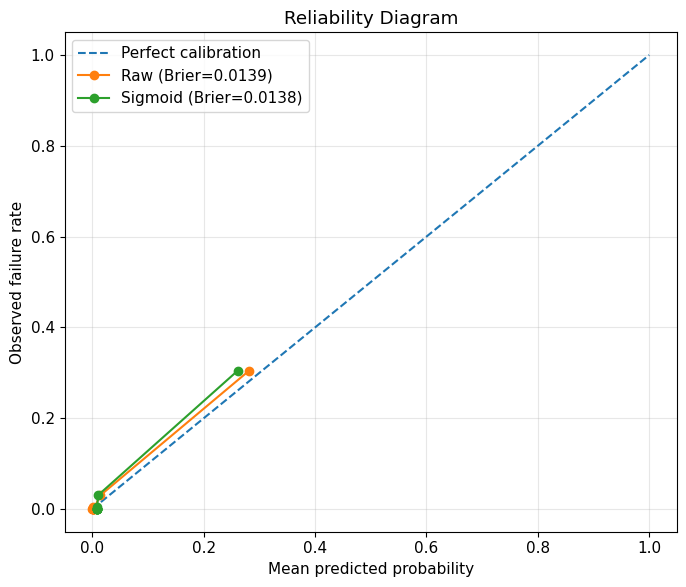

In [39]:
prob_true_raw, prob_pred_raw = calibration_curve(
    y_calib,
    p_cal_raw,
    n_bins=10,
    strategy="quantile"
)

prob_true_sig, prob_pred_sig = calibration_curve(
    y_calib,
    p_cal_sigmoid,
    n_bins=10,
    strategy="quantile"
)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

ax.plot(
    prob_pred_raw,
    prob_true_raw,
    marker="o",
    label=f"Raw (Brier={BRIER_BEFORE:.4f})"
)

ax.plot(
    prob_pred_sig,
    prob_true_sig,
    marker="o",
    label=f"Sigmoid (Brier={BRIER_AFTER:.4f})"
)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed failure rate")
ax.set_title("Reliability Diagram")
ax.legend()

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "calibration_curve.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Reliability Diagram Interpretation

The reliability diagram shows that both the raw and sigmoid-calibrated predictions are reasonably close to the perfect-calibration diagonal.

The raw model was already fairly well calibrated, which explains why the sigmoid adjustment produces only a small visible change.

The calibrated curve provides a slightly better probability scale overall, consistent with the small reduction in Brier score from **0.0139 to 0.0138**.

Because machine failures are rare, most predicted probabilities are concentrated near the lower end of the probability range, so the reliability points do not cover the full 0–1 interval.

In [40]:
if BRIER_AFTER < BRIER_BEFORE:

    USE_CALIBRATION = True
    FINAL_PREDICTOR = calibrated_model

    print("Calibration improved the Brier score.")
    print("The sigmoid-calibrated model is carried forward.")

else:

    USE_CALIBRATION = False
    FINAL_PREDICTOR = final_base_model

    print("Calibration did not improve the Brier score.")
    print("The raw selected model is retained.")

Calibration improved the Brier score.
The sigmoid-calibrated model is carried forward.


Calibration Selection

Sigmoid calibration is carried forward because it produced a lower Brier score than the raw model while preserving ROC-AUC and PR-AUC.

The improvement is small because the original LightGBM probabilities were already reasonably well calibrated. However, calibration improves the probability scale without sacrificing ranking performance, so the calibrated version is retained for the final pipeline.

In [41]:
if USE_CALIBRATION:

    order = np.argsort(p_cal_raw)

    FINAL_THRESHOLD = float(
        np.interp(
            SELECTED_THRESHOLD_RAW,
            p_cal_raw[order],
            p_cal_sigmoid[order]
        )
    )

    print(
        "Raw threshold:",
        round(SELECTED_THRESHOLD_RAW, 4)
    )

    print(
        "Equivalent sigmoid-calibrated threshold:",
        round(FINAL_THRESHOLD, 4)
    )

else:

    FINAL_THRESHOLD = SELECTED_THRESHOLD_RAW

    print(
        "Final threshold remains:",
        round(FINAL_THRESHOLD, 4)
    )

Raw threshold: 0.43
Equivalent sigmoid-calibrated threshold: 0.4139


Calibration Selection

Sigmoid calibration is carried forward because it produced a lower Brier score than the raw model while preserving ROC-AUC and PR-AUC.

The improvement is small because the original LightGBM probabilities were already reasonably well calibrated. However, calibration improves the probability scale without sacrificing ranking performance, so the calibrated version is retained for the final pipeline.

### Calibration — Interpretation

Calibration is evaluated independently from ranking performance.

If sigmoid calibration improves the Brier score while ROC-AUC and PR-AUC remain approximately unchanged, this is the expected behaviour: the ranking has been preserved while the numerical probability scale has been improved.

If sigmoid calibration does not improve the Brier score, the raw selected model is retained.

The final hold-out has not been used to fit the base model, the calibrator or the decision threshold.

If calibration is retained, the raw decision boundary is mapped to the calibrated probability scale rather than re-optimised on the final hold-out.

## 13. Model Comparison

The candidate models are compared using multiple criteria rather than selecting the largest AUC automatically.

The core comparison includes:
- baseline LightGBM,
- class-weighted LightGBM,
- Optuna-tuned LightGBM,
- calibrated selected model.

As an optional Day 3 extension, a second gradient-boosting model is used to test simple probability averaging and correct out-of-fold stacking.

The ensemble analysis is treated as bonus evidence rather than as a requirement for the final model.

In [42]:
def cross_validate_xgb(X_data, y_data, cv, scale_pos_weight=1.0):

    params = dict(
        learning_rate=0.05,
        n_estimators=2000,
        max_depth=5,
        min_child_weight=5.0,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,
        reg_alpha=0.0,
        gamma=0.0,
        tree_method="hist",
        enable_categorical=True,
        eval_metric="aucpr",
        early_stopping_rounds=100,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    oof = np.zeros(len(X_data))

    for fold, (tr_idx, va_idx) in enumerate(
        cv.split(X_data, y_data),
        start=1
    ):

        model = xgb.XGBClassifier(
            **params
        )

        model.fit(
            X_data.iloc[tr_idx],
            y_data.iloc[tr_idx],
            eval_set=[(
                X_data.iloc[va_idx],
                y_data.iloc[va_idx]
            )],
            verbose=False
        )

        oof[va_idx] = model.predict_proba(
            X_data.iloc[va_idx]
        )[:, 1]

        print(
            f"XGBoost fold {fold}: "
            f"PR-AUC = "
            f"{average_precision_score(y_data.iloc[va_idx], oof[va_idx]):.4f}"
        )

    return oof

In [43]:
oof_xgb = cross_validate_xgb(
    X_train,
    y_train,
    CV5,
    scale_pos_weight=FIXED_SCALE_POS_WEIGHT
)

XGB_ROC = roc_auc_score(
    y_train,
    oof_xgb
)

XGB_PR = average_precision_score(
    y_train,
    oof_xgb
)

print("\nXGBoost OOF ROC-AUC:", round(XGB_ROC, 4))
print("XGBoost OOF PR-AUC :", round(XGB_PR, 4))

XGBoost fold 1: PR-AUC = 0.7762
XGBoost fold 2: PR-AUC = 0.6948
XGBoost fold 3: PR-AUC = 0.6473
XGBoost fold 4: PR-AUC = 0.7648
XGBoost fold 5: PR-AUC = 0.7408

XGBoost OOF ROC-AUC: 0.9674
XGBoost OOF PR-AUC : 0.7142


XGBoost Comparison Interpretation

The optional XGBoost model achieved OOF ROC-AUC = **0.9674** and PR-AUC = **0.7142**.

Although this performance is still substantially above the rare-class baseline, it is clearly weaker than the selected LightGBM model, whose PR-AUC is **0.7958**.

XGBoost is therefore not selected as the primary model. Its main role here is to provide a second model for testing whether prediction diversity can improve an ensemble.

In [44]:
ensemble_oof_frame = pd.DataFrame({
    "lightgbm": SELECTED_OOF,
    "xgboost": oof_xgb,
})

print("OOF prediction correlation:")
print(
    ensemble_oof_frame
    .corr()
    .round(3)
)

oof_simple_average = (
    ensemble_oof_frame
    .mean(axis=1)
    .to_numpy()
)

SIMPLE_AVG_PR = average_precision_score(
    y_train,
    oof_simple_average
)

SIMPLE_AVG_ROC = roc_auc_score(
    y_train,
    oof_simple_average
)

print("\nSimple-average ROC-AUC:", round(SIMPLE_AVG_ROC, 4))
print("Simple-average PR-AUC :", round(SIMPLE_AVG_PR, 4))
print(
    "Gain over selected LightGBM:",
    round(
        SIMPLE_AVG_PR -
        average_precision_score(y_train, SELECTED_OOF),
        4
    )
)

OOF prediction correlation:
          lightgbm  xgboost
lightgbm     1.000    0.934
xgboost      0.934    1.000

Simple-average ROC-AUC: 0.9707
Simple-average PR-AUC : 0.7788
Gain over selected LightGBM: -0.017


Model Diversity Interpretation

The OOF prediction correlation between LightGBM and XGBoost is **0.934**, indicating that the two models produce very similar risk rankings.

This high correlation means that there is limited prediction diversity between the models. Because ensembles benefit most when component models make different errors, the potential benefit of combining these two models is expected to be limited.

In [45]:
meta_features = ensemble_oof_frame.to_numpy()

def stacked_oof(meta_X, y_true, seed=RANDOM_STATE):

    oof = np.zeros(len(y_true))

    meta_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    for tr_idx, va_idx in meta_cv.split(
        meta_X,
        y_true
    ):

        meta_model = LogisticRegression(
            max_iter=2000,
            random_state=seed
        )

        meta_model.fit(
            meta_X[tr_idx],
            y_true.iloc[tr_idx]
        )

        oof[va_idx] = meta_model.predict_proba(
            meta_X[va_idx]
        )[:, 1]

    return oof


oof_stack = stacked_oof(
    meta_features,
    y_train
)

STACK_ROC = roc_auc_score(
    y_train,
    oof_stack
)

STACK_PR = average_precision_score(
    y_train,
    oof_stack
)

print("Correct OOF stack ROC-AUC:", round(STACK_ROC, 4))
print("Correct OOF stack PR-AUC :", round(STACK_PR, 4))

Correct OOF stack ROC-AUC: 0.9701
Correct OOF stack PR-AUC : 0.7852


Simple-Average Ensemble Interpretation

A simple probability average of LightGBM and XGBoost achieved ROC-AUC = **0.9707** and PR-AUC = **0.7788**.

This is lower than the selected LightGBM PR-AUC of **0.7958**, producing a change of approximately **−0.017**.

The simple average therefore does not improve the model. This is consistent with the high correlation between the two base models and the weaker standalone performance of XGBoost.

In [46]:
def best_f1_operating_point(y_true, proba):

    table = threshold_sweep(
        y_true,
        proba
    )

    row = table.loc[
        table["f1"].idxmax()
    ]

    return {
        "threshold": float(row["threshold"]),
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1": float(row["f1"]),
        "flag_rate": float(row["flag_rate"]),
    }

In [47]:
baseline_point = best_f1_operating_point(
    y_train,
    oof_baseline
)

weighted_point = best_f1_operating_point(
    y_train,
    oof_weighted
)

tuned_point = best_f1_operating_point(
    y_train,
    oof_tuned
)

average_point = best_f1_operating_point(
    y_train,
    oof_simple_average
)

stack_point = best_f1_operating_point(
    y_train,
    oof_stack
)

comparison_rows = [
    {
        "Model": "Baseline LightGBM",
        "ROC-AUC": roc_auc_score(y_train, oof_baseline),
        "PR-AUC": average_precision_score(y_train, oof_baseline),
        "F1 under rule": baseline_point["f1"],
        "Threshold": baseline_point["threshold"],
        "Brier": brier_score_loss(y_train, oof_baseline),
        "Complexity": "Low",
    },
    {
        "Model": "Class-weighted LightGBM",
        "ROC-AUC": roc_auc_score(y_train, oof_weighted),
        "PR-AUC": average_precision_score(y_train, oof_weighted),
        "F1 under rule": weighted_point["f1"],
        "Threshold": weighted_point["threshold"],
        "Brier": brier_score_loss(y_train, oof_weighted),
        "Complexity": "Low",
    },
    {
        "Model": "Optuna-tuned LightGBM",
        "ROC-AUC": roc_auc_score(y_train, oof_tuned),
        "PR-AUC": average_precision_score(y_train, oof_tuned),
        "F1 under rule": tuned_point["f1"],
        "Threshold": tuned_point["threshold"],
        "Brier": brier_score_loss(y_train, oof_tuned),
        "Complexity": "Medium",
    },
    {
        "Model": "Selected model + sigmoid calibration",
        "ROC-AUC": CAL_SIG_ROC,
        "PR-AUC": CAL_SIG_PR,
        "F1 under rule": np.nan,
        "Threshold": FINAL_THRESHOLD if USE_CALIBRATION else np.nan,
        "Brier": BRIER_AFTER,
        "Complexity": "Medium",
    },
    {
        "Model": "Simple average (bonus)",
        "ROC-AUC": SIMPLE_AVG_ROC,
        "PR-AUC": SIMPLE_AVG_PR,
        "F1 under rule": average_point["f1"],
        "Threshold": average_point["threshold"],
        "Brier": brier_score_loss(y_train, oof_simple_average),
        "Complexity": "High",
    },
    {
        "Model": "OOF stack (bonus)",
        "ROC-AUC": STACK_ROC,
        "PR-AUC": STACK_PR,
        "F1 under rule": stack_point["f1"],
        "Threshold": stack_point["threshold"],
        "Brier": brier_score_loss(y_train, oof_stack),
        "Complexity": "High",
    },
]

model_comparison = pd.DataFrame(
    comparison_rows
)

print(
    model_comparison
    .round(4)
    .to_string(index=False)
)

                               Model  ROC-AUC  PR-AUC  F1 under rule  Threshold  Brier Complexity
                   Baseline LightGBM   0.9714  0.7958         0.7389     0.4300 0.0134        Low
             Class-weighted LightGBM   0.9698  0.7878         0.7462     0.6350 0.0152        Low
               Optuna-tuned LightGBM   0.9695  0.8024         0.7519     0.3450 0.0130     Medium
Selected model + sigmoid calibration   0.9757  0.7836            NaN     0.4139 0.0138     Medium
              Simple average (bonus)   0.9707  0.7788         0.7373     0.2600 0.0145       High
                   OOF stack (bonus)   0.9701  0.7852         0.7415     0.1350 0.0145       High


 Model Comparison Interpretation

The comparison table shows that the baseline LightGBM remains the strongest simplicity–performance trade-off.

The Optuna-tuned model has the highest OOF PR-AUC (**0.8024**), but its improvement over the baseline (**0.7958**) is too small relative to cross-validation variability to justify the extra tuning complexity.

Class weighting increases the F1 operating-point result but reduces PR-AUC, confirming that it mainly changes the decision behaviour rather than improving ranking quality.

The simple-average and stacked ensembles add operational complexity while failing to outperform the single LightGBM model.

The calibrated-model ROC-AUC and PR-AUC shown in this table come from the separate calibration split, whereas the main LightGBM rows are based on OOF training predictions; therefore, these values should not be interpreted as a direct same-sample ranking comparison. The purpose of the calibrated row is primarily to document its probability quality and selected calibrated threshold.

In [48]:
model_comparison.to_csv(
    RESULT_DIR / "model_results.csv",
    index=False
)

print(
    "Saved:",
    RESULT_DIR / "model_results.csv"
)

Saved: results/model_results.csv


## 14. Final Model Selection and Hold-Out Evaluation

The final system is the selected single LightGBM configuration, with sigmoid calibration only if calibration improved the Brier score.

The final decision threshold is fixed before the hold-out is opened.

The 20% final hold-out has not been used for:
- model training,
- cross-validation,
- imbalance selection,
- Optuna tuning,
- interpretability fitting,
- probability calibration,
- or threshold optimisation.

It is now opened exactly once to provide the project's final unbiased performance estimate.

No model, hyperparameter, feature, calibrator or threshold will be changed after this result is viewed.

In [49]:
p_holdout = FINAL_PREDICTOR.predict_proba(
    X_holdout
)[:, 1]

y_holdout_hat = (
    p_holdout >= FINAL_THRESHOLD
).astype(int)

FINAL_ROC = roc_auc_score(
    y_holdout,
    p_holdout
)

FINAL_PR = average_precision_score(
    y_holdout,
    p_holdout
)

FINAL_BRIER = brier_score_loss(
    y_holdout,
    p_holdout
)

FINAL_PRECISION = precision_score(
    y_holdout,
    y_holdout_hat,
    zero_division=0
)

FINAL_RECALL = recall_score(
    y_holdout,
    y_holdout_hat,
    zero_division=0
)

FINAL_F1 = f1_score(
    y_holdout,
    y_holdout_hat,
    zero_division=0
)

FINAL_CM = confusion_matrix(
    y_holdout,
    y_holdout_hat
)

print("=== FINAL HOLD-OUT RESULT ===")
print(f"Final model     : {SELECTED_SINGLE_NAME}")
print(f"Calibration used: {USE_CALIBRATION}")
print(f"Threshold       : {FINAL_THRESHOLD:.4f}")

print("\nRanking / probability metrics")
print(f"ROC-AUC : {FINAL_ROC:.4f}")
print(f"PR-AUC  : {FINAL_PR:.4f}")
print(f"Brier   : {FINAL_BRIER:.4f}")

print("\nDecision metrics")
print(f"Precision: {FINAL_PRECISION:.2%}")
print(f"Recall   : {FINAL_RECALL:.2%}")
print(f"F1       : {FINAL_F1:.4f}")

print("\nConfusion matrix:")
print(FINAL_CM)

print("\nClassification report:")
print(
    classification_report(
        y_holdout,
        y_holdout_hat,
        digits=3
    )
)

=== FINAL HOLD-OUT RESULT ===
Final model     : Baseline LightGBM
Calibration used: True
Threshold       : 0.4139

Ranking / probability metrics
ROC-AUC : 0.9713
PR-AUC  : 0.8117
Brier   : 0.0125

Decision metrics
Precision: 85.45%
Recall   : 69.12%
F1       : 0.7642

Confusion matrix:
[[1924    8]
 [  21   47]]

Classification report:
              precision    recall  f1-score   support

           0      0.989     0.996     0.993      1932
           1      0.855     0.691     0.764        68

    accuracy                          0.986      2000
   macro avg      0.922     0.844     0.878      2000
weighted avg      0.985     0.986     0.985      2000



Final Hold-Out Evaluation Interpretation

The final pipeline consists of the **baseline LightGBM model with sigmoid calibration** and a calibrated decision threshold of **0.4139**.

On the untouched 2,000-row final hold-out, the model achieved:

- **ROC-AUC = 0.9713**
- **PR-AUC = 0.8117**
- **Brier score = 0.0125**
- **Precision = 85.45%**
- **Recall = 69.12%**
- **F1 = 0.7642**

The confusion matrix contains **1,924 true negatives, 8 false positives, 21 false negatives and 47 true positives**.

Therefore, the final system correctly identifies 47 of the 68 true machine failures, while generating only eight false maintenance alerts. Approximately **69% of all failures are detected**, and approximately **85% of generated failure alerts are correct**.

The strong PR-AUC relative to the approximately 3.4% failure base rate, together with the low Brier score, indicates that the final pipeline maintains both strong ranking performance and good probability quality on completely unseen data.

In [50]:
SELECTED_CV_PR = average_precision_score(
    y_train,
    SELECTED_OOF
)

SELECTED_CV_ROC = roc_auc_score(
    y_train,
    SELECTED_OOF
)

print("=== CV vs FINAL HOLD-OUT ===")

print(
    f"CV ROC-AUC      : {SELECTED_CV_ROC:.4f}"
)
print(
    f"Hold-out ROC-AUC: {FINAL_ROC:.4f}"
)
print(
    f"Difference      : "
    f"{FINAL_ROC - SELECTED_CV_ROC:+.4f}"
)

print()

print(
    f"CV PR-AUC       : {SELECTED_CV_PR:.4f}"
)
print(
    f"Hold-out PR-AUC : {FINAL_PR:.4f}"
)
print(
    f"Difference      : "
    f"{FINAL_PR - SELECTED_CV_PR:+.4f}"
)

=== CV vs FINAL HOLD-OUT ===
CV ROC-AUC      : 0.9714
Hold-out ROC-AUC: 0.9713
Difference      : -0.0000

CV PR-AUC       : 0.7958
Hold-out PR-AUC : 0.8117
Difference      : +0.0159


Cross-Validation vs Hold-Out Interpretation

The final hold-out performance is highly consistent with the earlier cross-validation estimates.

ROC-AUC is almost identical:

- CV ROC-AUC = **0.9714**
- Hold-out ROC-AUC = **0.9713**

PR-AUC is slightly higher on the hold-out:

- CV PR-AUC = **0.7958**
- Hold-out PR-AUC = **0.8117**

The PR-AUC difference of approximately **+0.016** is small relative to the fold-to-fold variability observed during cross-validation.

Most importantly, there is no substantial performance collapse on the untouched hold-out. This supports the conclusion that the validation strategy produced a realistic estimate of generalisation performance.

In [51]:
final_row = pd.DataFrame([{
    "Model": "FINAL — hold-out result",
    "ROC-AUC": FINAL_ROC,
    "PR-AUC": FINAL_PR,
    "F1 under rule": FINAL_F1,
    "Threshold": FINAL_THRESHOLD,
    "Brier": FINAL_BRIER,
    "Complexity": "Final selected pipeline",
}])

final_model_comparison = pd.concat(
    [
        model_comparison,
        final_row
    ],
    ignore_index=True
)

print(
    final_model_comparison
    .round(4)
    .to_string(index=False)
)

final_model_comparison.to_csv(
    RESULT_DIR / "model_results.csv",
    index=False
)

                               Model  ROC-AUC  PR-AUC  F1 under rule  Threshold  Brier              Complexity
                   Baseline LightGBM   0.9714  0.7958         0.7389     0.4300 0.0134                     Low
             Class-weighted LightGBM   0.9698  0.7878         0.7462     0.6350 0.0152                     Low
               Optuna-tuned LightGBM   0.9695  0.8024         0.7519     0.3450 0.0130                  Medium
Selected model + sigmoid calibration   0.9757  0.7836            NaN     0.4139 0.0138                  Medium
              Simple average (bonus)   0.9707  0.7788         0.7373     0.2600 0.0145                    High
                   OOF stack (bonus)   0.9701  0.7852         0.7415     0.1350 0.0145                    High
             FINAL — hold-out result   0.9713  0.8117         0.7642     0.4139 0.0125 Final selected pipeline


Final Comparison Table Interpretation

The final row reports the one-time hold-out performance of the selected production pipeline; it is not an additional candidate model.

The earlier candidate rows describe cross-validation or calibration-stage evidence used during model development, while the final row provides the unbiased performance estimate on untouched data.

The final selected pipeline achieves PR-AUC = **0.8117**, F1 = **0.7642**, and Brier = **0.0125**, confirming that its performance remains strong after all modelling decisions were fixed.

In [52]:
from IPython.display import Markdown, display

final_name = (
    SELECTED_SINGLE_NAME + " + sigmoid calibration"
    if USE_CALIBRATION
    else SELECTED_SINGLE_NAME
)

rejected_reason = (
    "the ensemble / stack requires additional models and operational complexity, "
    "and any performance advantage must be interpreted relative to the measured "
    "cross-validation variability"
)

display(
    Markdown(
        f"""
### Final Model Selection

We select **{final_name}** as the final model.

**Reason:** It provides a strong balance between discrimination, the selected F1 operating rule, probability quality, reproducibility, interpretability and operational simplicity.

We rejected the more complex ensemble alternatives as the primary production recommendation because {rejected_reason}.

**Operating rule:** Maximum F1
**Threshold:** {FINAL_THRESHOLD:.4f}

**Hold-out performance:**
- ROC-AUC: **{FINAL_ROC:.4f}**
- PR-AUC: **{FINAL_PR:.4f}**
- Precision: **{FINAL_PRECISION:.2%}**
- Recall: **{FINAL_RECALL:.2%}**
- F1: **{FINAL_F1:.4f}**
- Brier score: **{FINAL_BRIER:.4f}**

The hold-out was opened only after the model, calibration decision and threshold were fixed.
"""
    )
)


### Final Model Selection

We select **Baseline LightGBM + sigmoid calibration** as the final model.

**Reason:** It provides a strong balance between discrimination, the selected F1 operating rule, probability quality, reproducibility, interpretability and operational simplicity.

We rejected the more complex ensemble alternatives as the primary production recommendation because the ensemble / stack requires additional models and operational complexity, and any performance advantage must be interpreted relative to the measured cross-validation variability.

**Operating rule:** Maximum F1  
**Threshold:** 0.4139

**Hold-out performance:**
- ROC-AUC: **0.9713**
- PR-AUC: **0.8117**
- Precision: **85.45%**
- Recall: **69.12%**
- F1: **0.7642**
- Brier score: **0.0125**

The hold-out was opened only after the model, calibration decision and threshold were fixed.


### Final Model Selection Interpretation

The final model is **Baseline LightGBM + sigmoid calibration**.

This model was selected because it provides the strongest overall balance of:

- high PR-AUC and ROC-AUC,
- a strong maximum-F1 operating point,
- good probability calibration,
- stable cross-validation behaviour,
- direct SHAP interpretability,
- and low operational complexity.

The Optuna-tuned LightGBM produced only a very small improvement relative to cross-validation variability. Class weighting changed the precision–recall operating point without improving ranking quality, while XGBoost and the ensemble alternatives did not outperform the single LightGBM model.

Sigmoid calibration was retained because it slightly improved the Brier score without changing ranking performance.

The final operating threshold is **0.4139**, corresponding to the original maximum-F1 threshold after calibration.

## 15. Conclusions, Limitations and Recommendations

### Conclusions

This project developed an end-to-end machine-failure classification workflow using the AI4I 2020 Predictive Maintenance Dataset.

The workflow began with leakage control and honest stratified cross-validation, then evaluated a LightGBM baseline using ROC-AUC and PR-AUC rather than relying on accuracy. Class weighting was measured rather than assumed to help, and the decision threshold was selected deliberately from out-of-fold scores instead of using the default 0.5 cut-off.

A small reproducible Optuna study tested whether the baseline could be improved beyond measured fold variability. Global permutation importance and SHAP were used to explain the model, while a local SHAP waterfall provided an explanation for an individual near-threshold case.

Probability calibration was evaluated on a dedicated calibration split using a reliability diagram and the Brier score. Finally, the selected pipeline was evaluated once on an untouched final hold-out.

### Limitations

1. **Synthetic data:** The AI4I dataset is synthetic, although it was designed to reflect industrial predictive-maintenance data. Performance on this dataset should not be assumed to transfer directly to a real plant.

2. **No temporal validation:** The supplied dataset has no timestamp defining deployment order, so deterioration over time and temporal drift cannot be evaluated.

3. **No repeated-machine validation:** There is no repeated machine identifier suitable for testing generalisation from known machines to completely unseen machines.

4. **Rare failures:** Machine failures represent only about 3.4% of observations, so estimates for the positive class are based on relatively few cases.

5. **No documented business cost matrix:** The dataset does not provide defensible monetary costs for missed failures or false alerts. Therefore, no costs were invented; F1 was used as the operating rule.

6. **Failure-mode labels cannot be predictors:** `TWF`, `HDF`, `PWF`, `OSF` and `RNF` were excluded because they directly determine the overall failure target and would create target leakage.

7. **Model explanations are not causal:** SHAP and permutation importance explain how the model uses variables; they do not prove that those variables causally produce machine failure.

### Recommendations

For a real deployment, the next step would be to validate the same workflow on genuine time-ordered equipment data containing repeated machine identities.

The maintenance team should also define the operational cost of missed failures and unnecessary inspections, or provide a review-capacity limit. This would allow the decision threshold to be selected using a real business objective rather than F1.

Model performance, calibration, class prevalence and important features should then be monitored over time to detect drift and determine an appropriate retraining schedule.

In [53]:
print("=== PROJECT OUTPUT CHECK ===")

expected_files = [
    IMAGE_DIR / "pr_curve.png",
    IMAGE_DIR / "threshold_curve.png",
    IMAGE_DIR / "calibration_curve.png",
    IMAGE_DIR / "shap_summary.png",
    IMAGE_DIR / "shap_waterfall.png",
    RESULT_DIR / "model_results.csv",
]

for path in expected_files:
    print(
        f"{'OK' if path.exists() else 'MISSING':<8}",
        path
    )

print("\nProject notebook workflow complete.")

=== PROJECT OUTPUT CHECK ===
OK       images/pr_curve.png
OK       images/threshold_curve.png
OK       images/calibration_curve.png
OK       images/shap_summary.png
OK       images/shap_waterfall.png
OK       results/model_results.csv

Project notebook workflow complete.
